In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import torch

from IPython.display import display, Latex
import subprocess

## Simplex Checker

## Performance Analysis

In [2]:
def find_matching_mlp_width(target_params, n_head, n_embd, dp=32, n_layer=4, vocab_size=65):
    # costs that are fixed regardless of mlp_width
    attn_params = n_layer * 4 * n_embd * n_head * dp  
    emb_params  = vocab_size * n_embd
    ln_params   = n_layer * 2 * (2 * n_embd) + 2 * n_embd

    remaining  = target_params - attn_params - emb_params - ln_params
    mlp_width  = remaining / (2 * n_embd * n_layer)   # 2 layers: c_fc + c_proj
    return int(mlp_width)

In [3]:
n_embd = 256
target_params = 5067520
find_matching_mlp_width(target_params, 32, n_embd)

416

32,512,4,32,8948736,184.67449307441711,6.189405918121338,4096
32,512,32,32,12618752,254.4006278514862,6.095646381378174,4096
32,512,64,32,16813056,331.38988041877747,6.047672271728516,4096

32,256,4,32,2377216,97.04327034950256,6.464170455932617,2048
32,256,11,32,2835968,105.43353986740112,6.481434345245361,2048
32,256,18,32,3294720,119.90641570091248,6.3535261154174805,2048
32,256,25,32,3753472,129.7913601398468,6.431674003601074,2048
32,256,32,32,4212224,135.6572151184082,6.341245174407959,2048
32,256,39,32,4670976,150.98751425743103,6.387723445892334,2048
32,256,46,32,5129728,157.94840598106384,6.420587062835693,2048


32,128,8,16,664320,67.49620819091797,7.754681587219238,1024
32,128,16,8,664320,69.69986271858215,7.68413782119751,1024
32,128,32,4,664320,75.20546197891235,7.6689910888671875,1024
32,256,8,32,1590784,82.21672463417053,6.499613761901856,1024
32,256,16,16,1590784,85.308926820755,6.395939350128174,1024
32,256,32,8,1590784,91.2087585926056,6.390689849853516,1024
32,512,8,64,4230144,125.48798274993896,6.834575653076172,1024
32,512,16,32,4230144,127.60994362831116,6.449573993682861,1024
32,512,32,16,4230144,131.82349920272827,6.2279558181762695,1024


In [10]:
np.arange(4,64,4)

array([ 4,  8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60])

## Results to demonstrate Thm 1

In [ ]:
32,128,4,4,287488,75.40416765213013,8.735513687133789,512
32,128,4,8,303872,76.80430245399475,8.424489974975586,512
32,128,4,16,336640,73.54965162277222,8.175213813781738,512
32,128,4,32,402176,62.78255844116211,7.766679763793945,512
32,128,4,50,475904,71.51786613464355,7.698112964630127,512


32,128,4,4,287488,75.40416765213013,8.735513687133789,512
32,128,4,8,303872,76.80430245399475,8.424489974975586,512
32,128,4,16,336640,73.54965162277222,8.175213813781738,512
32,128,4,32,402176,62.78255844116211,7.766679763793945,512
32,128,4,50,475904,71.51786613464355,7.698112964630127,512


In [12]:
for dp in np.arange(4,64,4):
    cmd = [
        "python", "train.py", "config/train_shakespeare_char.py",
        f"--dp={dp}",
    ]
    print(' '.join(cmd))
    subprocess.run(cmd)

python train.py config/train_shakespeare_char.py --dp=4
Overriding config with config/train_shakespeare_char.py:
Overriding: dp = 4
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 287488
num decayed parameter tensors: 10, with 290,944 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:03, 79.06it/s, loss=2.0023]                           


{'n': 32, 'd': 128, 'h': 4, 'dp': 4, 'n_params': 287488, 'mlp_width': 512, 'training_time': 63.812281131744385, 'perplexity': 8.735513687133789}
python train.py config/train_shakespeare_char.py --dp=8


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Overriding config with config/train_shakespeare_char.py:
Overriding: dp = 8
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 303872
num decayed parameter tensors: 10, with 307,328 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


...

{'n': 32, 'd': 128, 'h': 4, 'dp': 52, 'n_params': 484096, 'mlp_width': 512, 'training_time': 70.04823207855225, 'perplexity': 7.736023902893066}
python train.py config/train_shakespeare_char.py --dp=56
Overriding config with config/train_shakespeare_char.py:
Overriding: dp = 56
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 500480
num decayed parameter tensors: 10, with 503,936 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:19, 62.65it/s, loss=1.9066]                           


{'n': 32, 'd': 128, 'h': 4, 'dp': 56, 'n_params': 500480, 'mlp_width': 512, 'training_time': 80.43145370483398, 'perplexity': 7.650930404663086}
python train.py config/train_shakespeare_char.py --dp=60
Overriding config with config/train_shakespeare_char.py:
Overriding: dp = 60
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 516864
num decayed parameter tensors: 10, with 520,320 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:11, 69.92it/s, loss=1.8958]                           


{'n': 32, 'd': 128, 'h': 4, 'dp': 60, 'n_params': 516864, 'mlp_width': 512, 'training_time': 72.1206123828888, 'perplexity': 7.723504066467285}


In [25]:
from itertools import product
for ele in list(product([128, 256, 512], [8, 16, 32])):
    d = ele[0]
    h = ele[1]
    dp= d//h
    cmd = [
        "python", "train.py", "config/train_shakespeare_char.py",
        f"--n_embd={d}",
        f"--n_head={h}",
        f"--dp={dp}",
        f"--mlp_width={8*d}"
    ]
    print(' '.join(cmd))
    subprocess.run(cmd)

python train.py config/train_shakespeare_char.py --n_embd=128 --n_head=8 --dp=16
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 128
Overriding: n_head = 8
Overriding: dp = 16
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 664320
num decayed parameter tensors: 10, with 667,776 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:06, 74.72it/s, loss=1.9264]                           


{'n': 32, 'd': 128, 'h': 8, 'dp': 16, 'n_params': 664320, 'mlp_width': 1024, 'training_time': 67.49620819091797, 'perplexity': 7.754681587219238}
python train.py config/train_shakespeare_char.py --n_embd=128 --n_head=16 --dp=8
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 128
Overriding: n_head = 16
Overriding: dp = 8
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 664320
num decayed parameter tensors: 10, with 667,776 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:09, 72.35it/s, loss=1.9193]                          


{'n': 32, 'd': 128, 'h': 16, 'dp': 8, 'n_params': 664320, 'mlp_width': 1024, 'training_time': 69.69986271858215, 'perplexity': 7.68413782119751}
python train.py config/train_shakespeare_char.py --n_embd=128 --n_head=32 --dp=4
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 128
Overriding: n_head = 32
Overriding: dp = 4
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 664320
num decayed parameter tensors: 10, with 667,776 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


...

{'n': 32, 'd': 512, 'h': 8, 'dp': 64, 'n_params': 4230144, 'mlp_width': 1024, 'training_time': 125.48798274993896, 'perplexity': 6.834575653076172}
python train.py config/train_shakespeare_char.py --n_embd=512 --n_head=16 --dp=32
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 512
Overriding: n_head = 16
Overriding: dp = 32
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 4230144
num decayed parameter tensors: 10, with 4,243,968 parameters
num non-decayed parameter tensors: 5, with 2,560 parameters
using fused AdamW: False


Training: 5001it [02:06, 39.39it/s, loss=1.8202]                          


{'n': 32, 'd': 512, 'h': 16, 'dp': 32, 'n_params': 4230144, 'mlp_width': 1024, 'training_time': 127.60994362831116, 'perplexity': 6.449573993682861}
python train.py config/train_shakespeare_char.py --n_embd=512 --n_head=32 --dp=16
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 512
Overriding: n_head = 32
Overriding: dp = 16
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 4230144
num decayed parameter tensors: 10, with 4,243,968 parameters
num non-decayed parameter tensors: 5, with 2,560 parameters
using fused AdamW: False


Training: 5001it [02:11, 38.11it/s, loss=1.7981]                          


{'n': 32, 'd': 512, 'h': 32, 'dp': 16, 'n_params': 4230144, 'mlp_width': 1024, 'training_time': 131.82349920272827, 'perplexity': 6.2279558181762695}


In [2]:
from itertools import product
for ele in list(product([128, 256], [4,8, 16, 32, 40, 64])):
    d = ele[0]
    h = ele[1]
    dp= 32
    cmd = [
        "python", "train.py", "config/train_shakespeare_char.py",
        f"--n_embd={d}",
        f"--n_head={h}",
        f"--dp={dp}",
        f"--mlp_width={8*d}"
    ]
    print(' '.join(cmd))
    subprocess.run(cmd)

python train.py config/train_shakespeare_char.py --n_embd=128 --n_head=4 --dp=32 --mlp_width=1024
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 128
Overriding: n_head = 4
Overriding: dp = 32
Overriding: mlp_width = 1024
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 664320
num decayed parameter tensors: 10, with 667,776 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:08, 72.82it/s, loss=1.8986]                           


{'n': 32, 'd': 128, 'h': 4, 'dp': 32, 'n_params': 664320, 'mlp_width': 1024, 'training_time': 0, 'perplexity': 7.761092185974121}
python train.py config/train_shakespeare_char.py --n_embd=128 --n_head=8 --dp=32 --mlp_width=1024
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 128
Overriding: n_head = 8
Overriding: dp = 32
Overriding: mlp_width = 1024
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 795392
num decayed parameter tensors: 10, with 798,848 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


Training: 5001it [01:22, 60.27it/s, loss=1.8955]                          


{'n': 32, 'd': 128, 'h': 8, 'dp': 32, 'n_params': 795392, 'mlp_width': 1024, 'training_time': 0, 'perplexity': 7.605432510375977}
python train.py config/train_shakespeare_char.py --n_embd=128 --n_head=16 --dp=32 --mlp_width=1024
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 128
Overriding: n_head = 16
Overriding: dp = 32
Overriding: mlp_width = 1024
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 1057536
num decayed parameter tensors: 10, with 1,060,992 parameters
num non-decayed parameter tensors: 5, with 640 parameters
using fused AdamW: False


...

{'n': 32, 'd': 256, 'h': 32, 'dp': 32, 'n_params': 4212224, 'mlp_width': 2048, 'training_time': 0, 'perplexity': 6.693365097045898}
python train.py config/train_shakespeare_char.py --n_embd=256 --n_head=40 --dp=32 --mlp_width=2048
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 256
Overriding: n_head = 40
Overriding: dp = 32
Overriding: mlp_width = 2048
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 4736512
num decayed parameter tensors: 10, with 4,743,424 parameters
num non-decayed parameter tensors: 5, with 1,280 parameters
using fused AdamW: False


Training: 5001it [02:29, 33.39it/s, loss=1.7824]                          


{'n': 32, 'd': 256, 'h': 40, 'dp': 32, 'n_params': 4736512, 'mlp_width': 2048, 'training_time': 0, 'perplexity': 6.632531642913818}
python train.py config/train_shakespeare_char.py --n_embd=256 --n_head=64 --dp=32 --mlp_width=2048
Overriding config with config/train_shakespeare_char.py:
Overriding: n_embd = 256
Overriding: n_head = 64
Overriding: dp = 32
Overriding: mlp_width = 2048
tokens per iteration will be: 512
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 6309376
num decayed parameter tensors: 10, with 6,316,288 parameters
num non-decayed parameter tensors: 5, with 1,280 parameters
using fused AdamW: False


Training: 5001it [03:06, 26.83it/s, loss=1.7783]                          


{'n': 32, 'd': 256, 'h': 64, 'dp': 32, 'n_params': 6309376, 'mlp_width': 2048, 'training_time': 0, 'perplexity': 6.611839771270752}


In [6]:
df_bm = pd.read_csv("benchmark_results.csv")
df_fh = pd.read_csv("res2.csv")
df_fh2 = pd.read_csv("saved_res.csv")
df_fh3 = pd.read_csv("saved_128_res.csv")
df_mlp = pd.read_csv("mlp_width_vs_perp.csv")
df = pd.concat([df_fh, df_fh2, df_fh3.drop(columns=['Unnamed: 0'])])
df = df[df['n_params'] < 3565824].sort_values(by=['n_params'],ignore_index=True)
df_bm.sort_values(by=['n_params'], inplace=True)

32,256,4,32,1328640,79.60362339019775,6.582304954528809,1024
32,256,8,32,1590784,86.6478681564331,6.499613761901856,1024
32,256,16,32,2115072,100.00212216377258,6.557092666625977,1024
32,256,32,32,3163648,125.78887581825256,6.4342546463012695,1024
32,256,40,32,3687936,139.90471839904785,6.361696720123291,1024
32,256,64,32,5260800,180.77878975868225,6.467612266540527,1024
32,512,4,32,2657280,101.93840646743774,6.372341632843018,1024
32,512,8,32,3181568,112.73970556259157,6.514554023742676,1024
32,512,16,32,4230144,132.857492685318,6.449573993682861,1024
32,512,32,32,6327296,166.19296073913574,6.232838153839111,1024
32,512,40,32,7375872,186.05986976623527,6.371976375579834,1024
32,512,64,32,10521600,243.7760443687439,6.464360237121582,1024


In [7]:
df_bm = pd.read_csv("res_rand_samp_bm.csv")
df_fh = pd.read_csv("res_rand_samp_fh.csv")

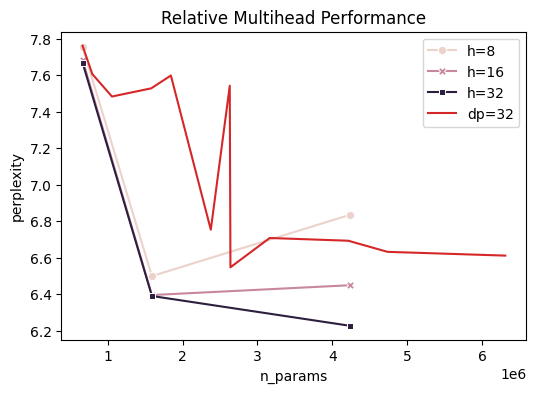

In [8]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
sns.lineplot(df_bm, x="n_params", y="perplexity", hue='h', dashes=False, style='h', markers=True, ax=ax)
# sns.lineplot(df_bm, x="n_params", y="perplexity",  markers=True, ax=ax, label="dp=32")
sns.lineplot(df_fh, x="n_params", y="perplexity",  markers=True, ax=ax, label="dp=32")
# sns.lineplot(df_fh[(mask & mask1) | (mask2 5.687430& mask3)], x="n_params", y="perplexity", markers=True, ax=ax[0])
ax.legend()
new_labels = ["h=8", "h=16", "h=32"]  # one per unique value of h
for t, l in zip(ax.get_legend().texts, new_labels):
    t.set_text(l)
ax.set_title(f"Relative Multihead Performance")
plt.savefig("images/perf.png")

In [8]:
def find_matching_n_head(target_params, dp=32, n_embd=256, n_layer=6, vocab_size=65):
    # Fixed costs regardless of n_head
    mlp_params  = n_layer * (2 * 4 * n_embd**2)        # c_fc + c_proj per layer
    emb_params  = vocab_size * n_embd                   # wte (wpe excluded as nanoGPT does)
    
    # Attention params per head
    attn_per_head = n_layer * 4 * n_embd * dp           # (c_attn + c_proj) per head per layer

    n_head = (target_params - mlp_params - emb_params) / attn_per_head
    return round(n_head)

In [9]:
find_matching_n_head(3565824)

2

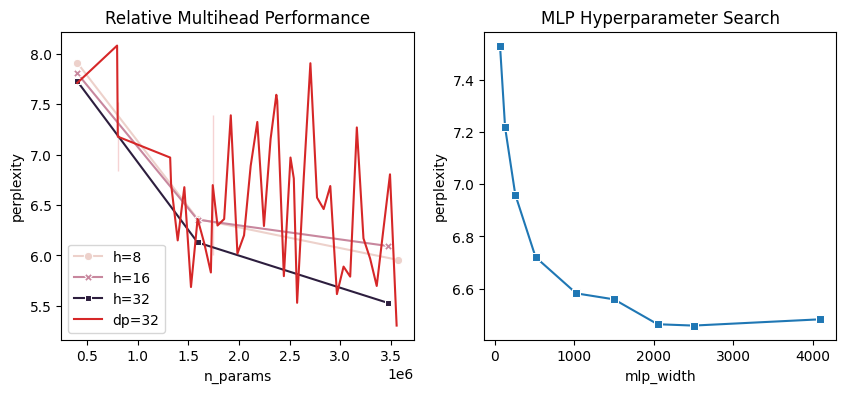

In [10]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
sns.lineplot(df_mlp, x="mlp_width", y="perplexity", marker="s", ax=ax[1])
ax[1].set_title("MLP Hyperparameter Search")

sns.lineplot(df_bm, x="n_params", y="perplexity", hue='h', dashes=False, style='h', markers=True, ax=ax[0])
sns.lineplot(df, x="n_params", y="perplexity",  markers=True, ax=ax[0], label="dp=32")

# sns.lineplot(df_fh[(mask & mask1) | (mask2 5.687430& mask3)], x="n_params", y="perplexity", markers=True, ax=ax[0])
ax[0].legend()
new_labels = ["h=8", "h=16", "h=32"]  # one per unique value of h
for t, l in zip(ax[0].get_legend().texts, new_labels):
    t.set_text(l)
ax[0].set_title(f"Relative Multihead Performance")

plt.savefig("images/perf.png")

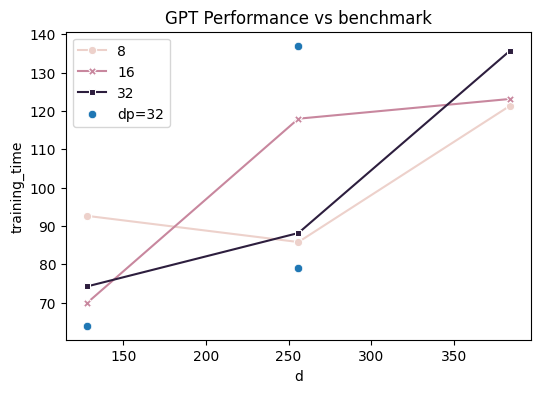

In [11]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
sns.lineplot(df_bm, x="d", y="training_time", hue='h', dashes=False, style='h', markers=True, ax=ax)
sns.scatterplot(df.loc[[0,9,47]], x="d", y="training_time",  markers=True, ax=ax, label="dp=32")
ax.legend()
ax.set_title(f"GPT Performance vs benchmark")
plt.show()

In [ ]:
32,512,4,32,2657280,101.93840646743774,6.372341632843018,1024
32,512,8,32,3181568,112.73970556259157,6.514554023742676,1024
32,512,16,32,4230144,132.857492685318,6.449573993682861,1024
32,512,32,32,6327296,166.19296073913574,6.232838153839111,1024
32,512,40,32,7375872,186.05986976623527,6.371976375579834,1024
32,512,64,32,10521600,243.7760443687439,6.464360237121582,1024



32,128,4,32,664320,66.72694325447083,7.5234293937683105,1024
32,128,8,32,795392,82.74226403236389,7.376391887664795,1024
32,128,16,32,1057536,88.4166214466095,7.214854717254639,1024
32,128,32,32,1581824,114.82116222381592,7.174042224884033,1024
32,128,40,32,1843968,108.59492206573486,7.246535301208496,1024
32,128,64,32,2630400,143.1236810684204,7.147461414337158,1024
32,256,4,32,1328640,79.60362339019775,6.582304954528809,1024
32,256,8,32,1590784,86.6478681564331,6.499613761901856,1024
32,256,16,32,2115072,100.00212216377258,6.557092666625977,1024
32,256,32,32,3163648,125.78887581825256,6.4342546463012695,1024
32,256,40,32,3687936,139.90471839904785,6.361696720123291,1024
32,256,64,32,5260800,180.77878975868225,6.467612266540527,1024



Yes, because as we established the fundamental issue is not `dp` — it's that **this entire experimental setup is the wrong regime for the paper's result**.

## The Regime Mismatch

| | Paper (LM1B) | Your Setup |
|---|---|---|
| sequence length | 256 | 32 |
| vocab size | 32k | 65 |
| dataset size | 1B tokens | 1M tokens |
| model size | 16-30M params | ~1-4M params |
| n_layer | 6 | 2 |

## Why Fixed-dp Cannot Win Here

The paper's result requires **all three** of these conditions simultaneously:

**1. Task must be hard enough** — 65 character vocab with short sequences is nearly solved by derived multihead at modest parameter counts. There's no headroom for fixed-dp to show improvement.

**2. Model must be deep enough** — with `n_layer=2`, each attention layer has to do enormous work. Derived multihead with `dp=n_embd/n_head` keeps each layer's attention perfectly matched to the residual stream. Fixed-dp with more heads adds capacity but the 2-layer depth can't exploit it.

**3. Data must be sufficient** — with 1M tokens and `max_iters=5000` you're seeing each token ~2.5 times. The model never gets enough signal to exploit the extra expressiveness that fixed-dp provides.

## To Actually Replicate the Paper

You would need to move to a harder setup:

```python
# Minimum viable setup to see fixed-dp advantage
block_size = 256   # longer sequences → low-rank bottleneck actually binds
n_layer    = 6     # deeper model → more benefit from expressive attention
dataset    = 'openwebtext'  # larger, harder dataset
dp         = 32    # = sequence_length from paper's perspective
# then sweep n_head from 4 → 70
```

TinyShakespeare with `block_size=32` is simply too easy — it's the wrong dataset to validate this paper's claims on.